##  Install dependencies

In [1]:
!pip install -q transformers datasets seqeval accelerate sentencepiece protobuf
import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


##  Upload data files

In [2]:
from google.colab import files
print("Upload data.json and test_data.json")
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Upload data.json and test_data.json


Saving data.json to data.json
Saving test_data.json to test_data.json
Uploaded: ['data.json', 'test_data.json']


##  Imports

In [3]:
import json, random, re, string, warnings
from collections import Counter
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

LABEL_LIST = ["O", "B-PER", "I-PER", "B-EMAIL", "I-EMAIL"]
LABEL2ID   = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}
print("Labels:", LABEL2ID)


Labels: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-EMAIL': 3, 'I-EMAIL': 4}


##  Load data

In [4]:
with open("data.json") as f:
    train_raw = json.load(f)
with open("test_data.json") as f:
    test_synthetic_raw=json.load(f)

print(f"Train samples : {len(train_raw):,}")
print(json.dumps(train_raw[0], indent=2))

Train samples : 28,516
{
  "lang": "en",
  "ner_tags": [
    "O",
    "O",
    "O",
    "O",
    "B-PER",
    "I-PER",
    "O",
    "O",
    "O",
    "O",
    "B-PER",
    "I-PER",
    "O",
    "O",
    "O",
    "O",
    "O",
    "B-PER",
    "I-PER",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
  ],
  "sequence": "Since then , only Terry Bradshaw in 147 games , Joe Montana in 139 games , and Tom Brady in 131 games have reached 100 wins more quickly .",
  "tokens": [
    "Since",
    "then",
    ",",
    "only",
    "Terry",
    "Bradshaw",
    "in",
    "147",
    "games",
    ",",
    "Joe",
    "Montana",
    "in",
    "139",
    "games",
    ",",
    "and",
    "Tom",
    "Brady",
    "in",
    "131",
    "games",
    "have",
    "reached",
    "100",
    "wins",
    "more",
    "quickly",
    "."
  ]
}


This is done to create an independent data by smartly filtering out the data from the NeuralWiki itself  and injecting real names using faker library

In [5]:
from datasets import load_dataset

wiki = load_dataset("Babelscape/wikineural")

WIKI_TAG_MAP = {0: "O", 1: "B-PER", 2: "I-PER"}

def convert_wikineural_sample(sample):
    tokens = sample["tokens"]
    tags = [WIKI_TAG_MAP.get(t, "O") for t in sample["ner_tags"]]
    return {"tokens": tokens, "ner_tags": tags}

wiki_test_raw = [convert_wikineural_sample(s) for s in wiki["test_en"]]

# Safety check to make sure no sentences overlap with training data
train_sentences = set(" ".join(s["tokens"]) for s in train_raw)
wiki_test_raw = [s for s in wiki_test_raw if " ".join(s["tokens"]) not in train_sentences]
print(f"After overlap removal: {len(wiki_test_raw):,} samples")

test_raw = wiki_test_raw[:2500]
print(f"Independent test samples : {len(test_raw):,}")

per_count = sum(1 for s in test_raw for t in s["ner_tags"] if t == "B-PER")
print(f"PER entities in test set: {per_count:,}")

README.md: 0.00B [00:00, ?B/s]

data/test_de-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

data/test_en-00000-of-00001.parquet:   0%|          | 0.00/894k [00:00<?, ?B/s]

data/test_es-00000-of-00001.parquet:   0%|          | 0.00/723k [00:00<?, ?B/s]

data/test_fr-00000-of-00001.parquet:   0%|          | 0.00/997k [00:00<?, ?B/s]

...

Generating val_nl split:   0%|          | 0/10460 [00:00<?, ? examples/s]

Generating val_pl split:   0%|          | 0/13520 [00:00<?, ? examples/s]

Generating val_pt split:   0%|          | 0/10070 [00:00<?, ? examples/s]

Generating val_ru split:   0%|          | 0/11540 [00:00<?, ? examples/s]

After overlap removal: 11,597 samples
Independent test samples : 2,500
PER entities in test set: 1,116


##  Email injections

In [6]:

TRAIN_DOMAINS = [
    "gmail.com", "yahoo.com", "outlook.com", "hotmail.com",
    "protonmail.com", "icloud.com", "company.com", "example.org"
]
# Completely different to check how good has it been generalised
TEST_DOMAINS = [
    "uni.edu.pk", "mail.gov.uk", "work.io",
    "company.co", "dept.org", "web.net"
]
SEPARATORS = [".", "_", ""]


def tokenize_email(local: str, domain: str):
    """

    e.g. alfred.hitchcock@gmail.com
      -> ["alfred", ".", "hitchcock", "@", "gmail", ".", "com"]
         [B-EMAIL, I-EMAIL, I-EMAIL,  I-EMAIL, I-EMAIL, I-EMAIL, I-EMAIL]

    """
    _SPLIT_RE = re.compile(r"([@.])")
    full_email = f"{local}@{domain}"
    parts = [p for p in _SPLIT_RE.split(full_email) if p]
    assert len(parts) >= 3, f"Bad email tokenisation: {parts}"
    tags = ["B-EMAIL"] + ["I-EMAIL"] * (len(parts) - 1)
    return parts, tags


def _find_per_ends(tags):
    """Return list of indices just after each PER span."""
    per_ends = []
    i = 0
    while i < len(tags):
        if tags[i] == "B-PER":
            j = i + 1
            while j < len(tags) and tags[j] == "I-PER":
                j += 1
            per_ends.append(j)
            i = j
        else:
            i += 1
    return per_ends


def _name_parts(tokens, tags, ins):
    """Extract first/last name from the PER span ending at ins."""
    j = ins - 1
    name_toks = []
    while j >= 0 and tags[j] in ("B-PER", "I-PER"):
        name_toks.insert(0, tokens[j])
        j -= 1
    first = name_toks[0] if name_toks else None
    last  = name_toks[-1] if len(name_toks) > 1 else None
    return first, last



def inject_email_train(sample, prob=0.30):
    tokens = list(sample["tokens"])
    tags   = list(sample["ner_tags"])
    if random.random() > prob:
        return {"tokens": tokens, "ner_tags": tags}
    per_ends = _find_per_ends(tags)
    if not per_ends:
        return {"tokens": tokens, "ner_tags": tags}
    ins = random.choice(per_ends)
    first, last = _name_parts(tokens, tags, ins)

    fmt = random.randint(0, 3)
    if fmt == 0 and first and last:
        sep   = random.choice(SEPARATORS)
        num   = random.choice(["", str(random.randint(1, 99))])
        local = f"{first.lower()}{sep}{last.lower()}{num}"
    elif fmt == 1 and first:
        local = f"{first.lower()}{random.randint(1,999)}"
    elif fmt == 2 and last:
        local = last.lower() + random.choice(["_work", ".official", ""])
    else:
        local = "".join(random.choices(string.ascii_lowercase + string.digits, k=random.randint(5, 12)))
    domain = random.choice(TRAIN_DOMAINS)
    email_tokens, email_tags = tokenize_email(local, domain)
    new_tokens = tokens[:ins] + email_tokens + tokens[ins:]
    new_tags   = tags[:ins]   + email_tags   + tags[ins:]
    assert len(new_tokens) == len(new_tags)
    return {"tokens": new_tokens, "ner_tags": new_tags}



def inject_email_test(sample, prob=0.25):
    tokens = list(sample["tokens"])
    tags   = list(sample["ner_tags"])
    if random.random() > prob:
        return {"tokens": tokens, "ner_tags": tags}
    per_ends = _find_per_ends(tags)
    if not per_ends:
        return {"tokens": tokens, "ner_tags": tags}
    if random.random() < 0.5:
      ins = random.choice(per_ends)
    else:
      ins = random.randint(0, len(tokens))
    first, last = _name_parts(tokens, tags, ins)
    fmt = random.randint(0, 3)
    if fmt == 0 and first and last:
        local = f"{last.lower()}-{first.lower()[0]}"    # smith-j
    elif fmt == 1 and first and last:
        local = f"{first.lower()[0]}{last.lower()}"     # jsmith
    elif fmt == 2:
        local = str(random.randint(100000, 999999))     # 847291
    else:
        local = "".join(random.choices(string.ascii_lowercase, k=6)) + str(random.randint(10, 99))
    domain = random.choice(TEST_DOMAINS)               # unseen domains
    email_tokens, email_tags = tokenize_email(local, domain)
    new_tokens = tokens[:ins] + email_tokens + tokens[ins:]
    new_tags   = tags[:ins]   + email_tags   + tags[ins:]
    assert len(new_tokens) == len(new_tags)
    return {"tokens": new_tokens, "ner_tags": new_tags}


train_injected = [inject_email_train(s, 0.30) for s in train_raw]
test_injected  = [inject_email_test(s, 0.25)  for s in test_raw]
test_synthetic_injected=[inject_email_test(s, 0.25)  for s in test_synthetic_raw]
with open("test_synthetic_injected.json", "w") as f:
    json.dump(test_synthetic_injected, f, indent=2)
def tag_counts(data):
    c = Counter()
    for s in data: c.update(s["ner_tags"])
    return c

print("Train tag distribution after injection:")
tc = tag_counts(train_injected)
for t in LABEL_LIST: print(f"  {t:12}: {tc[t]:,}")

print("\nTest tag distribution after injection:")
tc2 = tag_counts(test_injected)
for t in LABEL_LIST: print(f"  {t:12}: {tc2[t]:,}")

ex = next(s for s in train_injected if "B-EMAIL" in s["ner_tags"])
print("\nTrain injected example (non-O tokens only):")
for tok, tag in zip(ex["tokens"], ex["ner_tags"]):
    if tag != "O": print(f"  {tok!r:40} -> {tag}")

ex2 = next(s for s in test_injected if "B-EMAIL" in s["ner_tags"])
print("\nTest injected example (non-O tokens only):")
for tok, tag in zip(ex2["tokens"], ex2["ner_tags"]):
    if tag != "O": print(f"  {tok!r:40} -> {tag}")


Train tag distribution after injection:
  O           : 639,055
  B-PER       : 40,264
  I-PER       : 29,466
  B-EMAIL     : 8,508
  I-EMAIL     : 35,880

Test tag distribution after injection:
  O           : 55,883
  B-PER       : 1,116
  I-PER       : 819
  B-EMAIL     : 204
  I-EMAIL     : 936

Train injected example (non-O tokens only):
  'Anthony'                                -> B-PER
  'Perkins'                                -> I-PER
  'Alfred'                                 -> B-PER
  'Hitchcock'                              -> I-PER
  'alfred229'                              -> B-EMAIL
  '@'                                      -> I-EMAIL
  'outlook'                                -> I-EMAIL
  '.'                                      -> I-EMAIL
  'com'                                    -> I-EMAIL

Test injected example (non-O tokens only):
  'Constant'                               -> B-PER
  'Detré'                                  -> I-PER
  'cdetré'                   

##  Tokenising & aligning labels

In [7]:
MODEL_NAME = "bert-base-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
    )
    all_label_ids = []
    for i, tag_seq in enumerate(examples["ner_tags"]):
        word_ids  = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word:
                label_ids.append(LABEL2ID[tag_seq[wid]])
            else:
                label_ids.append(-100)
            prev_word = wid
        all_label_ids.append(label_ids)
    tokenized["labels"] = all_label_ids
    return tokenized


def build_dataset(data):
    ds = Dataset.from_dict({
        "tokens":   [s["tokens"]   for s in data],
        "ner_tags": [s["ner_tags"] for s in data],
    })
    return ds.map(tokenize_and_align, batched=True, remove_columns=["tokens", "ner_tags"])


full_train_ds = build_dataset(train_injected)
test_ds       = build_dataset(test_injected)
test_synthetic_ds = build_dataset(test_synthetic_injected)

split    = full_train_ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
val_ds   = split["test"]

print(f"Train : {len(train_ds):,}")
print(f"Val   : {len(val_ds):,}")
print(f"Test  : {len(test_ds):,}")

valid_ids = set(range(len(LABEL_LIST))) | {-100}
assert all(l in valid_ids for l in train_ds[0]["labels"]), "Bad label id!"
print("Label alignment sanity check: PASSED")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/28516 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/3650 [00:00<?, ? examples/s]

Train : 25,664
Val   : 2,852
Test  : 2,500
Label alignment sanity check: PASSED


##  Load model

In [8]:
import gc
try: del model
except: pass
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_LIST),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
print(f"Model loaded : {MODEL_NAME}")
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Device       : {'GPU' if torch.cuda.is_available() else 'CPU'}")


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Model loaded : bert-base-cased
Parameters   : 107,723,525
Device       : GPU


##  Metrics

In [9]:
def compute_metrics(p):

    preds, labels = p
    preds = np.argmax(preds, axis=2)

    true_labels = [[ID2LABEL[l] for l in lseq if l != -100] for lseq in labels]
    true_preds  = [
        [ID2LABEL[pr] for pr, l in zip(pseq, lseq) if l != -100]
        for pseq, lseq in zip(preds, labels)
    ]

    prec = precision_score(true_labels, true_preds)
    rec  = recall_score(true_labels, true_preds)
    f1   = f1_score(true_labels, true_preds)

    flat_true = [t for seq in true_labels for t in seq]
    flat_pred = [t for seq in true_preds  for t in seq]

    tp = sum(1 for t, p in zip(flat_true, flat_pred) if t != "O" and p != "O")
    tn = sum(1 for t, p in zip(flat_true, flat_pred) if t == "O" and p == "O")
    fp = sum(1 for t, p in zip(flat_true, flat_pred) if t == "O" and p != "O")
    fn = sum(1 for t, p in zip(flat_true, flat_pred) if t != "O" and p == "O")

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0
    fpr      = fp / (fp + tn) if (fp + tn) else 0.0
    fnr      = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        "accuracy":  accuracy,
        "fpr":       fpr,
        "fnr":       fnr,
        "precision": prec,
        "recall":    rec,
        "f1":        f1,
    }


##  Train

In [10]:
import shutil, os
if os.path.exists("./pii_model"): shutil.rmtree("./pii_model")

data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    output_dir="./pii_model",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    bf16=False,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Fpr,Fnr,Precision,Recall,F1
1,0.007824,0.008253,0.997854,0.001514,0.005703,0.980066,0.985942,0.982995
2,0.003873,0.007159,0.998026,0.001155,0.006580,0.983065,0.984081,0.983573
3,0.003065,0.007917,0.998119,0.001233,0.005527,0.983921,0.986769,0.985343


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2406, training_loss=0.03792227393500847, metrics={'train_runtime': 410.4328, 'train_samples_per_second': 187.587, 'train_steps_per_second': 5.862, 'total_flos': 3081588893385600.0, 'train_loss': 0.03792227393500847, 'epoch': 3.0})

##  Final evaluation on Independent test set

FINAL EVALUATION ON HELD-OUT TEST SET



Accuracy  : 0.9938
FPR       : 0.0061  (O tokens predicted as PII)
FNR       : 0.0068  (PII tokens predicted as O)
Precision : 0.8017
Recall    : 0.9781
F1        : 0.8812

Per-entity classification report:
              precision    recall  f1-score   support

       EMAIL       0.94      0.98      0.96       204
         PER       0.78      0.98      0.87      1123

   micro avg       0.80      0.98      0.88      1327
   macro avg       0.86      0.98      0.91      1327
weighted avg       0.81      0.98      0.88      1327



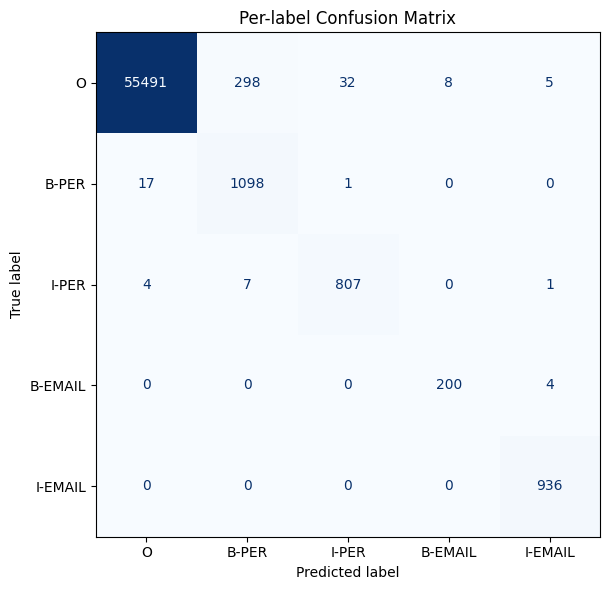


Raw confusion matrix (rows=true, cols=pred):
             O         B-PER     I-PER     B-EMAIL   I-EMAIL 
O               55491       298        32         8         5
B-PER              17      1098         1         0         0
I-PER               4         7       807         0         1
B-EMAIL             0         0         0       200         4
I-EMAIL             0         0         0         0       936


In [11]:
print("=" * 60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 60)

pred_out       = trainer.predict(test_ds)
preds_argmax   = np.argmax(pred_out.predictions, axis=2)
test_label_ids = pred_out.label_ids

true_seqs = [[ID2LABEL[l] for l in seq if l != -100] for seq in test_label_ids]
pred_seqs = [
    [ID2LABEL[p] for p, l in zip(pseq, lseq) if l != -100]
    for pseq, lseq in zip(preds_argmax, test_label_ids)
]

# Token level counts
flat_true = [t for seq in true_seqs for t in seq]
flat_pred = [t for seq in pred_seqs for t in seq]

tp = sum(1 for t, p in zip(flat_true, flat_pred) if t != "O" and p != "O")
tn = sum(1 for t, p in zip(flat_true, flat_pred) if t == "O" and p == "O")
fp = sum(1 for t, p in zip(flat_true, flat_pred) if t == "O" and p != "O")
fn = sum(1 for t, p in zip(flat_true, flat_pred) if t != "O" and p == "O")

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0
fpr      = fp / (fp + tn) if (fp + tn) else 0.0
fnr      = fn / (fn + tp) if (fn + tp) else 0.0

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"FPR       : {fpr:.4f}  (O tokens predicted as PII)")
print(f"FNR       : {fnr:.4f}  (PII tokens predicted as O)")

# Span level metrics (seqeval)
print(f"Precision : {precision_score(true_seqs, pred_seqs):.4f}")
print(f"Recall    : {recall_score(true_seqs, pred_seqs):.4f}")
print(f"F1        : {f1_score(true_seqs, pred_seqs):.4f}")

print("\nPer-entity classification report:")
print(classification_report(true_seqs, pred_seqs))

# Confusion matrix
labels_cm = ["O", "B-PER", "I-PER", "B-EMAIL", "I-EMAIL"]
cm = confusion_matrix(flat_true, flat_pred, labels=labels_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_cm)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Per-label Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nRaw confusion matrix (rows=true, cols=pred):")
print(f"{''         :12}", "  ".join(f"{l:8}" for l in labels_cm))
for i, row in enumerate(cm):
    print(f"{labels_cm[i]:12}", "  ".join(f"{v:8}" for v in row))


##Evaluation on the test set given

FINAL EVALUATION ON Synthetic TEST SET



Accuracy  : 0.9967
FPR       : 0.0027  (O tokens predicted as PII)
FNR       : 0.0070  (PII tokens predicted as O)
Precision : 0.9667
Recall    : 0.9811
F1        : 0.9738

Per-entity classification report:
              precision    recall  f1-score   support

       EMAIL       0.93      0.98      0.96       947
         PER       0.97      0.98      0.98      5229

   micro avg       0.97      0.98      0.97      6176
   macro avg       0.95      0.98      0.97      6176
weighted avg       0.97      0.98      0.97      6176



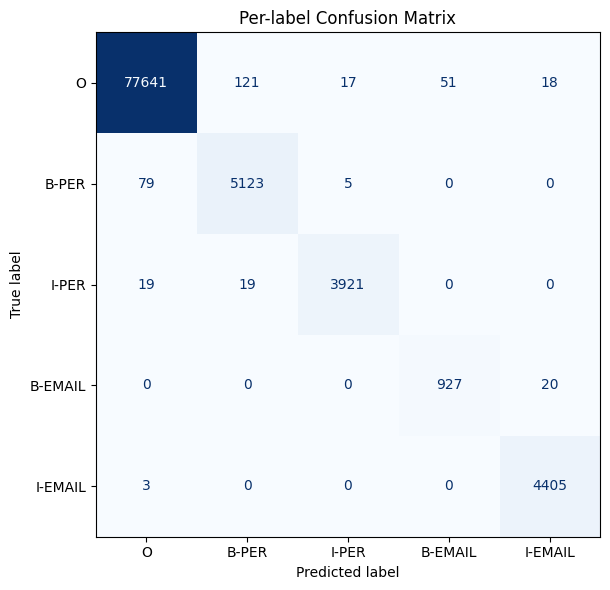


Raw confusion matrix (rows=true, cols=pred):
             O         B-PER     I-PER     B-EMAIL   I-EMAIL 
O               77641       121        17        51        18
B-PER              79      5123         5         0         0
I-PER              19        19      3921         0         0
B-EMAIL             0         0         0       927        20
I-EMAIL             3         0         0         0      4405


In [12]:

print("FINAL EVALUATION ON Synthetic TEST SET")


pred_out       = trainer.predict(test_synthetic_ds)
preds_argmax   = np.argmax(pred_out.predictions, axis=2)
test_label_ids = pred_out.label_ids

true_seqs = [[ID2LABEL[l] for l in seq if l != -100] for seq in test_label_ids]
pred_seqs = [
    [ID2LABEL[p] for p, l in zip(pseq, lseq) if l != -100]
    for pseq, lseq in zip(preds_argmax, test_label_ids)
]

# Token-level counts
flat_true = [t for seq in true_seqs for t in seq]
flat_pred = [t for seq in pred_seqs for t in seq]

tp = sum(1 for t, p in zip(flat_true, flat_pred) if t != "O" and p != "O")
tn = sum(1 for t, p in zip(flat_true, flat_pred) if t == "O" and p == "O")
fp = sum(1 for t, p in zip(flat_true, flat_pred) if t == "O" and p != "O")
fn = sum(1 for t, p in zip(flat_true, flat_pred) if t != "O" and p == "O")

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0
fpr      = fp / (fp + tn) if (fp + tn) else 0.0
fnr      = fn / (fn + tp) if (fn + tp) else 0.0

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"FPR       : {fpr:.4f}  (O tokens predicted as PII)")
print(f"FNR       : {fnr:.4f}  (PII tokens predicted as O)")

# Span-level metrics (seqeval)
print(f"Precision : {precision_score(true_seqs, pred_seqs):.4f}")
print(f"Recall    : {recall_score(true_seqs, pred_seqs):.4f}")
print(f"F1        : {f1_score(true_seqs, pred_seqs):.4f}")

print("\nPer-entity classification report:")
print(classification_report(true_seqs, pred_seqs))

#  Confusion matrix
labels_cm = ["O", "B-PER", "I-PER", "B-EMAIL", "I-EMAIL"]
cm = confusion_matrix(flat_true, flat_pred, labels=labels_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_cm)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Per-label Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nRaw confusion matrix (rows=true, cols=pred):")
print(f"{''         :12}", "  ".join(f"{l:8}" for l in labels_cm))
for i, row in enumerate(cm):
    print(f"{labels_cm[i]:12}", "  ".join(f"{v:8}" for v in row))

##  Error analysis

In [13]:
print("COMMON ERRORS\n")
errors = []
for i, (true_seq, pred_seq, sample) in enumerate(zip(true_seqs, pred_seqs, test_injected)):
    for j, (t, p) in enumerate(zip(true_seq, pred_seq)):
        if t != p:
            tok = sample["tokens"][j] if j < len(sample["tokens"]) else "<trunc>"
            errors.append({"token": tok, "true": t, "pred": p, "sentence_id": i})

print(f"Total mismatches: {len(errors):,}")
print(f"\nError breakdown (true -> predicted):")
err_counts = Counter((e["true"], e["pred"]) for e in errors)
for (true, pred), count in err_counts.most_common(10):
    print(f"  {true:12} -> {pred:12} : {count:,} times")

print("\nSample error tokens:")
for e in errors[:10]:
    print(f"  {e['token']!r:35} | true={e['true']:12} | pred={e['pred']}")


COMMON ERRORS

Total mismatches: 230

Error breakdown (true -> predicted):
  O            -> B-PER        : 80 times
  B-PER        -> O            : 54 times
  O            -> B-EMAIL      : 30 times
  I-PER        -> B-PER        : 16 times
  I-PER        -> O            : 15 times
  O            -> I-PER        : 13 times
  O            -> I-EMAIL      : 8 times
  B-EMAIL      -> I-EMAIL      : 8 times
  B-PER        -> I-PER        : 3 times
  I-EMAIL      -> O            : 3 times

Sample error tokens:
  'the'                               | true=O            | pred=B-PER
  'city'                              | true=O            | pred=I-PER
  '<trunc>'                           | true=O            | pred=B-EMAIL
  'of'                                | true=O            | pred=B-PER
  'insisted'                          | true=O            | pred=B-EMAIL
  'announced'                         | true=O            | pred=B-PER
  'her'                               | true=O           

## LLM zero shot comparison
Uses both the model that I had access too.

In [14]:
!pip install groq openai scikit-learn numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.6 MB/s eta 0:00:00


In [16]:
import json, os, time, re
import numpy as np
from groq import Groq
from openai import OpenAI
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
)

from google.colab import userdata


GROQ_API_KEY = userdata.get("GROQ_API_KEY")
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

groq_client    = Groq(api_key=GROQ_API_KEY)
openai_client  = OpenAI(api_key=OPENAI_API_KEY)


with open("test_synthetic_injected.json") as f:
    test_synthetic_injected = json.load(f)

print(f"✅ Loaded {len(test_synthetic_injected)} samples")


VALID_TAGS = {"O", "B-PER", "I-PER", "B-EMAIL", "I-EMAIL"}
PII_LABELS = ["B-PER", "I-PER", "B-EMAIL", "I-EMAIL"]
ALL_LABELS = ["O", "B-PER", "I-PER", "B-EMAIL", "I-EMAIL"]
N_SAMPLES  = 250


SYSTEM_PROMPT = """You are an expert Named Entity Recognition (NER) system for PII detection. Assign a BIO tag to EVERY token in the input list.

TAGS:
  O        → not a named entity
  B-PER    → first token of a person's name
  I-PER    → continuation of the same person's name
  B-EMAIL  → first token of an email address (the local part, BEFORE the @ symbol)
  I-EMAIL  → every subsequent token of that email: the @, the domain parts, the dots, and the TLD

EMAIL DETECTION — READ THIS CAREFULLY

Emails in this data are ALWAYS split into multiple tokens. The structure is:
  [local_part] [@] [domain] [.] [tld]   — each is a separate token

The @ symbol is your PRIMARY ANCHOR:
  • The token IMMEDIATELY BEFORE @ → always B-EMAIL
  • The @ token itself              → always I-EMAIL
  • Every token AFTER @ through the TLD → always I-EMAIL (including all dots)

The local part (token before @) can look like any of these:
  • Alphanumeric codes:  epbtcw78, zkpyxr31, kdfzyb68
  • Pure numbers:        562888, 254583, 405397
  • Lowercase names:     jhickenlooper, mhamdaoui, glee
  • Name-dash-initial:   meloy-c, rexach-c, logg-e

Email domains always end at one of these TLDs: net, pk, co, io, org, uk
  → The token after the TLD is ALWAYS O (the email is over)

If a person's name (B-PER/I-PER) is immediately followed by a local-part+@ pattern,
start B-EMAIL immediately — do NOT extend I-PER into the email tokens.

PERSON NAME RULES

  • First token of a name → B-PER
  • Each additional token in the SAME name → I-PER
  • Honorifics and titles (Mr, Mrs, Ms, Dr, Prof, Sir, Lord, Father, Rev) → O (not part of the name entity)
  • A name span ends the moment you see B-EMAIL, O, or a new B-PER

OUTPUT FORMAT

Return ONLY a valid JSON array of strings. No markdown. No explanation. No extra text.
The array length MUST equal the number of input tokens exactly.
"""

USER_TEMPLATE = "Label every token. Return a JSON array of exactly {n} tags.\n\nTokens ({n} total): {tokens}"

def fix_bio(tags):
    fixed, prev = [], "O"
    for tag in tags:
        if tag.startswith("I-"):
            entity = tag[2:]
            if not (prev == f"B-{entity}" or prev == f"I-{entity}"):
                tag = f"B-{entity}"
        fixed.append(tag)
        prev = tag
    return fixed

def parse_tags(content, n):
    content = re.sub(r"```[a-z]*", "", content).strip()
    match = re.search(r"\[.*?\]", content, re.DOTALL)
    if match:
        try:
            tags = json.loads(match.group())
            tags = [t.strip() if t.strip() in VALID_TAGS else "O" for t in tags]
            tags = fix_bio(tags)
            if len(tags) >= n:
                return tags[:n]
            return tags + ["O"] * (n - len(tags))
        except (json.JSONDecodeError, TypeError):
            pass
    found = re.findall(r'"(O|B-PER|I-PER|B-EMAIL|I-EMAIL)"', content)
    if found:
        found = fix_bio(found)
        return (found + ["O"] * n)[:n]
    return ["O"] * n


def call_groq(tokens, retries=3):
    prompt = USER_TEMPLATE.format(n=len(tokens), tokens=json.dumps(tokens))
    for attempt in range(retries):
        try:
            resp = groq_client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                          {"role": "user",   "content": prompt}],
                temperature=0, max_tokens=600,
            )
            return parse_tags(resp.choices[0].message.content, len(tokens))
        except Exception as e:
            wait = 2 ** attempt
            print(f"  [Groq] attempt {attempt+1} failed: {e}. Retrying in {wait}s…")
            time.sleep(wait)
    return ["O"] * len(tokens)

def call_gpt4o(tokens, retries=3):
    prompt = USER_TEMPLATE.format(n=len(tokens), tokens=json.dumps(tokens))
    for attempt in range(retries):
        try:
            resp = openai_client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                          {"role": "user",   "content": prompt}],
                temperature=0, max_tokens=600,
            )
            return parse_tags(resp.choices[0].message.content, len(tokens))
        except Exception as e:
            wait = 2 ** attempt
            print(f"  [GPT-4o] attempt {attempt+1} failed: {e}. Retrying in {wait}s…")
            time.sleep(wait)
    return ["O"] * len(tokens)


def compute_metrics(y_true, y_pred):
    flat_true = [t for seq in y_true for t in seq]
    flat_pred = [t for seq in y_pred for t in seq]

    token_acc = accuracy_score(flat_true, flat_pred)

    p_arr, r_arr, f1_arr, sup_arr = precision_recall_fscore_support(
        flat_true, flat_pred, labels=ALL_LABELS, average=None, zero_division=0
    )
    per_class = {
        lbl: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
        for lbl, p, r, f, s in zip(ALL_LABELS, p_arr, r_arr, f1_arr, sup_arr)
    }

    pii_idx = [i for i, l in enumerate(ALL_LABELS) if l in PII_LABELS]
    p_pii  = float(np.mean([p_arr[i]  for i in pii_idx]))
    r_pii  = float(np.mean([r_arr[i]  for i in pii_idx]))
    f1_pii = float(np.mean([f1_arr[i] for i in pii_idx]))

    bin_true = [1 if t != "O" else 0 for t in flat_true]
    bin_pred = [1 if t != "O" else 0 for t in flat_pred]
    cm = confusion_matrix(bin_true, bin_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, 0)
    fpr = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
    fnr = float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0

    return {
        "token_accuracy":  round(token_acc, 4),
        "macro_precision": round(p_pii,     4),
        "macro_recall":    round(r_pii,     4),
        "macro_f1":        round(f1_pii,    4),
        "fpr":             round(fpr,       4),
        "fnr":             round(fnr,       4),
        "per_class":       per_class,
    }


def run_evaluation(test_data, model, n=N_SAMPLES, delay=0.4):
    caller = call_groq if model == "groq" else call_gpt4o
    y_true, y_pred, errors = [], [], []

    print(f"\n{'='*60}")
    print(f"  Running: {model.upper()}  ({n} samples)")
    print(f"{'='*60}")

    for i, ex in enumerate(test_data[:n]):
        tokens    = ex["tokens"]
        true_tags = ex["ner_tags"]
        pred_tags = caller(tokens)

        y_true.append(true_tags)
        y_pred.append(pred_tags)
        if len(pred_tags) != len(true_tags):
            errors.append(i)
        if (i + 1) % 50 == 0:
            print(f"  [{model.upper()}] {i+1}/{n} done …")
        time.sleep(delay)

    metrics = compute_metrics(y_true, y_pred)
    metrics["parse_errors"] = len(errors)
    return metrics, y_true, y_pred


def print_results(name, metrics):
    print(f"\n╔{'═'*52}╗")
    print(f"║  {name:<50}║")
    print(f"╚{'═'*52}╝")
    print(f"  Token Accuracy    : {metrics['token_accuracy']:.4f}")
    print(f"  Macro Precision   : {metrics['macro_precision']:.4f}  (PII labels only)")
    print(f"  Macro Recall      : {metrics['macro_recall']:.4f}  (PII labels only)")
    print(f"  Macro F1-Score    : {metrics['macro_f1']:.4f}  (PII labels only)")
    print(f"  False Positive R  : {metrics['fpr']:.4f}  (binary: PII vs O)")
    print(f"  False Negative R  : {metrics['fnr']:.4f}  (binary: PII vs O)")
    print(f"  Parse Errors      : {metrics['parse_errors']}")
    print(f"\n  {'Tag':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'─'*52}")
    for lbl, v in metrics["per_class"].items():
        print(f"  {lbl:<12} {v['precision']:>10.4f} {v['recall']:>10.4f} "
              f"{v['f1']:>10.4f} {v['support']:>10}")

def compare_models(m1, m2, n1="Groq LLaMA-3.1-8B", n2="GPT-4o"):
    print(f"\n{'='*68}")
    print("  HEAD-TO-HEAD COMPARISON")
    print(f"{'='*68}")
    keys = [
        ("token_accuracy",  "Token Accuracy"),
        ("macro_precision", "Macro Precision"),
        ("macro_recall",    "Macro Recall"),
        ("macro_f1",        "F1"),
        ("fpr",             "False Positive Rate ↓"),
        ("fnr",             "False Negative Rate ↓"),
    ]
    print(f"  {'Metric':<24} {n1:>20} {n2:>10} {'Winner':>12}")
    print(f"  {'─'*68}")
    for key, label in keys:
        v1, v2 = m1[key], m2[key]
        if key in ("fpr", "fnr"):
            winner = n1 if v1 < v2 else (n2 if v2 < v1 else "tie")
        else:
            winner = n1 if v1 > v2 else (n2 if v2 > v1 else "tie")
        print(f"  {label:<24} {v1:>20.4f} {v2:>10.4f} {winner:>12}")



print("  ZERO-SHOT PII MASKING EVALUATION")
print(f"  Samples : {N_SAMPLES}  |  Models : Groq LLaMA-3.1-8B  vs  GPT-4o")


groq_metrics, groq_true, groq_pred = run_evaluation(
    test_synthetic_injected, model="groq", n=N_SAMPLES, delay=0.5
)

gpt_metrics, gpt_true, gpt_pred = run_evaluation(
    test_synthetic_injected, model="gpt4o", n=N_SAMPLES, delay=0.3
)

print_results("Groq  LLaMA-3.1-8B-Instant  (Zero-Shot)", groq_metrics)
print_results("OpenAI GPT-4o  (Zero-Shot)", gpt_metrics)
compare_models(groq_metrics, gpt_metrics)

with open("pii_eval_results.json", "w") as f:
    json.dump({"groq_llama_8b": groq_metrics, "gpt4o": gpt_metrics}, f, indent=2)
print("\n✅ Results saved → pii_eval_results.json")

✅ Loaded 3650 samples
  ZERO-SHOT PII MASKING EVALUATION
  Samples : 250  |  Models : Groq LLaMA-3.1-8B  vs  GPT-4o

  Running: GROQ  (250 samples)
  [GROQ] 50/250 done …
  [GROQ] 100/250 done …
  [GROQ] 150/250 done …
  [GROQ] 200/250 done …
  [Groq] attempt 1 failed: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kqqafznnf2ab4f2e81fzgr5z` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 4735, Requested 1289. Please try again in 240ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}. Retrying in 1s…
  [GROQ] 250/250 done …

  Running: GPT4O  (250 samples)
  [GPT4O] 50/250 done …
  [GPT4O] 100/250 done …
  [GPT4O] 150/250 done …
  [GPT4O] 200/250 done …
  [GPT4O] 250/250 done …

╔════════════════════════════════════════════════════╗
║  Groq  LLaMA-3.1-8B-Instant  (Zero-Shot)           ║
╚══════════════════

##  Save everything

In [17]:
trainer.save_model("./pii_model_final")
tokenizer.save_pretrained("./pii_model_final")
print("Model saved to ./pii_model_final")

shutil.make_archive("pii_model_final", "zip", "./pii_model_final")
files.download("pii_model_final.zip")
print("Done! Model downloaded.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./pii_model_final


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Model downloaded.
